# 📊 Lead Scoring Prediction using Machine Learning

## Internship Project

### Submitted By:
**Rashali Bajaj**

**B.Tech Computer Science & Engineering**  
**DIT University, Dehradun**

---

### Project Objective

The objective of this project is to build a Machine Learning model that predicts whether a lead will convert into a paying customer. Based on the predicted probability, each lead is assigned a Lead Score, enabling the sales team to prioritize high-potential leads and improve conversion rates.

---

### Dataset

**Dataset Name:** Lead Scoring Dataset

**Source:** Kaggle

---


# 1. Business Understanding

## Problem Statement

X Education is an online education company that generates a large number of leads through various online marketing channels. However, only around 30% of these leads convert into paying customers.

Currently, the sales team treats every lead equally, resulting in time and effort being spent on low-potential leads.

The goal of this project is to build a Machine Learning model that predicts whether a lead will convert into a paying customer. Based on the predicted probability, a Lead Score can be assigned to each lead, helping the sales team prioritize high-quality leads and improve conversion rates.

## Machine Learning Objective

Develop a Binary Classification model that predicts whether a lead will convert into a paying customer.

### Target Variable

Converted

- 1 → Converted
- 0 → Not Converted

# 2. Import Required Libraries

In this step, we import all the libraries required for data manipulation, visualization, preprocessing, and machine learning.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# 3. Load the Dataset

The dataset is loaded into a Pandas DataFrame for further analysis and preprocessing.

In [2]:
df = pd.read_csv("Lead Scoring.csv")

# 4. Initial Data Exploration

Before cleaning the dataset, we first understand its structure by examining the number of rows and columns, data types, summary statistics, and sample records.

This helps us identify potential data quality issues and plan the preprocessing steps.

In [3]:
df.shape

(9240, 37)

In [4]:
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [6]:
df.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


In [7]:
df.columns

Index(['Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source',
       'Do Not Email', 'Do Not Call', 'Converted', 'TotalVisits',
       'Total Time Spent on Website', 'Page Views Per Visit', 'Last Activity',
       'Country', 'Specialization', 'How did you hear about X Education',
       'What is your current occupation',
       'What matters most to you in choosing a course', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses', 'Tags', 'Lead Quality',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'Lead Profile', 'City', 'Asymmetrique Activity Index',
       'Asymmetrique Profile Index', 'Asymmetrique Activity Score',
       'Asymmetrique Profile Score',
       'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='object')

# Observations from Initial Data Exploration

After exploring the dataset, the following observations were made:

- The dataset contains **9,240 rows** and **37 columns**.
- The target variable is **Converted**, indicating whether a lead converted into a customer.
- The dataset contains both **numerical** and **categorical** features.
- Some columns contain a significant number of missing values.
- Several columns appear to be identifier columns and may not contribute to prediction.
- Further data cleaning and preprocessing are required before model building.

# 5. Data Preprocessing

## Objective

Prepare the dataset for analysis and machine learning by handling missing values, duplicates, outliers, categorical variables, and other data-quality issues.

### 5.1 Missing Value Analysis

In [8]:
df.isnull().sum()

,0
Prospect ID,0
Lead Number,0
Lead Origin,0
Lead Source,36
Do Not Email,0
Do Not Call,0
Converted,0
TotalVisits,137
Total Time Spent on Website,0
Page Views Per Visit,137


In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

,0
Lead Quality,51.590909
Asymmetrique Profile Index,45.649351
Asymmetrique Activity Score,45.649351
Asymmetrique Activity Index,45.649351
Asymmetrique Profile Score,45.649351
Tags,36.287879
What matters most to you in choosing a course,29.318182
Lead Profile,29.318182
What is your current occupation,29.112554
Country,26.634199


### 5.2 Identify Placeholder Values

Some categorical features contain `Select` as an unselected response. These values are identified before deciding how to handle missing data.

In [10]:
df.apply(lambda col: col.astype(str).str.strip().eq('Select').sum())

,0
Prospect ID,0
Lead Number,0
Lead Origin,0
Lead Source,0
Do Not Email,0
Do Not Call,0
Converted,0
TotalVisits,0
Total Time Spent on Website,0
Page Views Per Visit,0


### 5.3 Standardize Missing Values

Placeholder values such as `Select` are converted to `NaN` so that missing data can be analyzed and handled consistently.

In [11]:
df.replace('Select', np.nan, inplace=True)

In [12]:
missing_count = df.isnull().sum()
missing_count = missing_count[missing_count > 0]

missing_count.sort_values(ascending=False)

,0
How did you hear about X Education,7250
Lead Profile,6855
Lead Quality,4767
Asymmetrique Activity Index,4218
Asymmetrique Profile Index,4218
Asymmetrique Profile Score,4218
Asymmetrique Activity Score,4218
City,3669
Specialization,3380
Tags,3353


In [13]:
missing_percentage = (missing_count / len(df)) * 100
missing_percentage.sort_values(ascending=False)

,0
How did you hear about X Education,78.463203
Lead Profile,74.188312
Lead Quality,51.590909
Asymmetrique Activity Index,45.649351
Asymmetrique Profile Index,45.649351
Asymmetrique Profile Score,45.649351
Asymmetrique Activity Score,45.649351
City,39.707792
Specialization,36.580087
Tags,36.287879


### 5.4 Feature-wise Missing Value Treatment

Features with high missing values are evaluated based on missingness, business relevance, and information content before deciding whether to drop or impute them.

In [14]:
df['Lead Quality'].value_counts(dropna=False)

,count
Lead Quality,
NaN,4767
Might be,1560
Not Sure,1092
High in Relevance,637
Worst,601
Low in Relevance,583


In [15]:
df['Lead Quality'] = df['Lead Quality'].fillna('Unknown')

In [16]:
df['Tags'].value_counts(dropna=False).head(15)

,count
Tags,
NaN,3353
Will revert after reading the email,2072
Ringing,1203
Interested in other courses,513
Already a student,465
Closed by Horizzon,358
switched off,240
Busy,186
Lost to EINS,175


### Observation – Tags

`Tags` contains meaningful lead-interaction information but has a high percentage of missing values. Since some tags may be generated during the sales process, the feature will be checked for potential data leakage before deciding whether to retain it.

In [17]:
df['Lead Profile'].value_counts(dropna=False)

,count
Lead Profile,
NaN,6855
Potential Lead,1613
Other Leads,487
Student of SomeSchool,241
Lateral Student,24
Dual Specialization Student,20


### Observation – Lead Profile

`Lead Profile` contains 74.19% missing values, leaving limited observed information. Therefore, the feature is dropped due to its high missingness and limited reliable information.

In [18]:
df.drop(columns=['Lead Profile'], inplace=True)

### Observation – Asymmetrique Features

The Asymmetrique features contain approximately 45.65% missing values. Their distributions are examined before deciding whether to retain or remove them.

In [19]:
asym_cols = [
    'Asymmetrique Activity Index',
    'Asymmetrique Profile Index',
    'Asymmetrique Activity Score',
    'Asymmetrique Profile Score'
]

df[asym_cols].describe()

,Asymmetrique Activity Score,Asymmetrique Profile Score
count,5022.000000,5022.000000
mean,14.306252,16.344883
std,1.386694,1.811395
min,7.000000,11.000000
25%,14.000000,15.000000
50%,14.000000,16.000000
75%,15.000000,18.000000
max,18.000000,20.000000


### Observation – Asymmetrique Features

The Asymmetrique features have approximately 45.65% missing values and limited variation. Considering their high missingness and relatively low information content, these features are removed.

In [20]:
df.drop(columns=asym_cols, inplace=True)

In [21]:
df['City'].value_counts(dropna=False).head(15)

,count
City,
NaN,3669
Mumbai,3222
Thane & Outskirts,752
Other Cities,686
Other Cities of Maharashtra,457
Other Metro Cities,380
Tier II Cities,74


### Observation – City

`City` contains meaningful geographical categories with 39.71% missing values. The feature is retained, and missing values will be treated as `Unknown`.

In [22]:
df['City'] = df['City'].fillna('Unknown')

In [23]:
df['Specialization'].value_counts(dropna=False).head(20)

,count
Specialization,
NaN,3380
Finance Management,976
Human Resource Management,848
Marketing Management,838
Operations Management,503
Business Administration,403
IT Projects Management,366
Supply Chain Management,349
"Banking, Investment And Insurance",338


### Observation – Specialization

`Specialization` contains meaningful categories with 36.58% missing values. The feature is retained, and missing values will be treated as `Unknown`.

In [24]:
df['Specialization'] = df['Specialization'].fillna('Unknown')

In [25]:
df['What matters most to you in choosing a course'].value_counts(dropna=False)

,count
What matters most to you in choosing a course,
Better Career Prospects,6528
NaN,2709
Flexibility & Convenience,2
Other,1


### Observation – Course Preference

The feature is dominated by `Better Career Prospects` but contains 29.32% missing values. The feature is retained, with missing values treated as `Unknown`.

In [26]:
df['What matters most to you in choosing a course'] = \
    df['What matters most to you in choosing a course'].fillna('Unknown')

In [27]:
df['What is your current occupation'].value_counts(dropna=False)

,count
What is your current occupation,
Unemployed,5600
NaN,2690
Working Professional,706
Student,210
Other,16
Housewife,10
Businessman,8


### Observation – Current Occupation

The feature contains meaningful occupation categories with 29.11% missing values. It is retained, with missing values treated as `Unknown`.

In [28]:
df['What is your current occupation'] = \
    df['What is your current occupation'].fillna('Unknown')

In [29]:
df['Country'].value_counts(dropna=False).head(15)

,count
Country,
India,6492
NaN,2461
United States,69
United Arab Emirates,53
Singapore,24
Saudi Arabia,21
United Kingdom,15
Australia,13
Qatar,10


### Observation – Country

`Country` contains useful geographical information with 26.63% missing values. The feature is retained, with missing values treated as `Unknown`.

In [30]:
df['Country'] = df['Country'].fillna('Unknown')

In [31]:
df['How did you hear about X Education'].value_counts(dropna=False)

,count
How did you hear about X Education,
NaN,7250
Online Search,808
Word Of Mouth,348
Student of SomeSchool,310
Other,186
Multiple Sources,152
Advertisements,70
Social Media,67
Email,26


In [32]:
df['How did you hear about X Education'] = \
    df['How did you hear about X Education'].fillna('Unknown')

### 5.5 Low-Missing Features

Features with a small proportion of missing values are retained and handled according to their data type and distribution.

In [33]:
df['TotalVisits'].describe()

,TotalVisits
count,9103.000000
mean,3.445238
std,4.854853
min,0.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,251.000000


In [34]:
df['Page Views Per Visit'].describe()

,Page Views Per Visit
count,9103.000000
mean,2.362820
std,2.161418
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,55.000000


In [35]:
df[['Last Activity', 'Lead Source']].isnull().sum()

,0
Last Activity,103
Lead Source,36


In [36]:
df['Last Activity'].value_counts(dropna=False)

,count
Last Activity,
Email Opened,3437
SMS Sent,2745
Olark Chat Conversation,973
Page Visited on Website,640
Converted to Lead,428
Email Bounced,326
Email Link Clicked,267
Form Submitted on Website,116
NaN,103


In [37]:
df['Lead Source'].value_counts(dropna=False)

,count
Lead Source,
Google,2868
Direct Traffic,2543
Olark Chat,1755
Organic Search,1154
Reference,534
Welingak Website,142
Referral Sites,125
Facebook,55
NaN,36


### Categorical Missing Value Treatment

`Last Activity` and `Lead Source` contain very few missing values. Since their missing proportion is negligible, missing values are imputed using the mode of each feature.

In [38]:
df['Last Activity'] = df['Last Activity'].fillna(
    df['Last Activity'].mode()[0]
)

df['Lead Source'] = df['Lead Source'].fillna(
    df['Lead Source'].mode()[0]
)

In [39]:
df[['Last Activity', 'Lead Source']].isnull().sum()

,0
Last Activity,0
Lead Source,0


In [40]:
missing_count = df.isnull().sum()
missing_count = missing_count[missing_count > 0]
missing_count.sort_values(ascending=False)

,0
Tags,3353
TotalVisits,137
Page Views Per Visit,137


### Observation – Tags

`Tags` contains interaction and follow-up status information. Since these values may be recorded after sales interactions, the feature is checked for potential temporal data leakage before model training.

In [41]:
df.drop(columns=['Tags'], inplace=True)

### 5.6 Duplicate Handling

Duplicate records are identified and removed to prevent repeated observations from biasing model training.

In [42]:
# Check and remove duplicate records
duplicate_count = df.duplicated().sum()

print("Duplicate records found:", duplicate_count)

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")
else:
    print("No duplicate records found.")

print("Dataset shape after duplicate handling:", df.shape)

Duplicate records found: 0
No duplicate records found.
Dataset shape after duplicate handling: (9240, 31)


### 5.7 Identifier and Constant Feature Check

Identifier and constant features are identified because they generally provide little or no predictive information and may add unnecessary complexity to the model.

In [43]:
# Identify identifier-like columns
identifier_cols = [
    col for col in df.columns
    if df[col].nunique() == len(df)
]

# Identify constant columns
constant_cols = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 1
]

print("Identifier-like columns:", identifier_cols)
print("Constant columns:", constant_cols)

Identifier-like columns: ['Prospect ID', 'Lead Number']
Constant columns: ['Magazine', 'Receive More Updates About Our Courses', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'I agree to pay the amount through cheque']


### Observation – Identifier and Constant Features

Identifier columns and constant features provide no meaningful predictive variation. They are removed to reduce unnecessary features and model complexity.

In [44]:
# Remove identifier and constant features
drop_cols = identifier_cols + constant_cols

df.drop(columns=drop_cols, inplace=True)

print("Dropped columns:", drop_cols)
print("Dataset shape after removal:", df.shape)

Dropped columns: ['Prospect ID', 'Lead Number', 'Magazine', 'Receive More Updates About Our Courses', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'I agree to pay the amount through cheque']
Dataset shape after removal: (9240, 24)


### 5.12 Outlier Analysis

Potential outliers in numerical features are identified using the IQR method. Outliers are evaluated before deciding whether any treatment is necessary.

In [45]:
# Identify numerical features
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude target variable
numeric_features = [col for col in numeric_cols if col != 'Converted']

outlier_summary = {}

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower_bound) |
                     (df[col] > upper_bound)).sum()

    outlier_summary[col] = outlier_count

outlier_summary = pd.Series(outlier_summary).sort_values(ascending=False)

print("Potential outliers by feature:")
print(outlier_summary)

Potential outliers by feature:
Page Views Per Visit           360
TotalVisits                    267
Total Time Spent on Website      0
dtype: int64


### Observation – Outliers

Potential outliers are present in `TotalVisits` and `Page Views Per Visit`. Since these values may represent genuine high-engagement leads, they will not be removed blindly. Their impact will be evaluated during EDA and model development.

## 6. Exploratory Data Analysis



### 6.1 Target Variable Distribution

The distribution of `Converted` is analyzed to understand the proportion of converted and non-converted leads and identify potential class imbalance.

In [46]:
# Target distribution
print(df['Converted'].value_counts())
print("\nTarget percentage:")
print(df['Converted'].value_counts(normalize=True) * 100)

Converted
0    5679
1    3561
Name: count, dtype: int64

Target percentage:
Converted
0    61.461039
1    38.538961
Name: proportion, dtype: float64


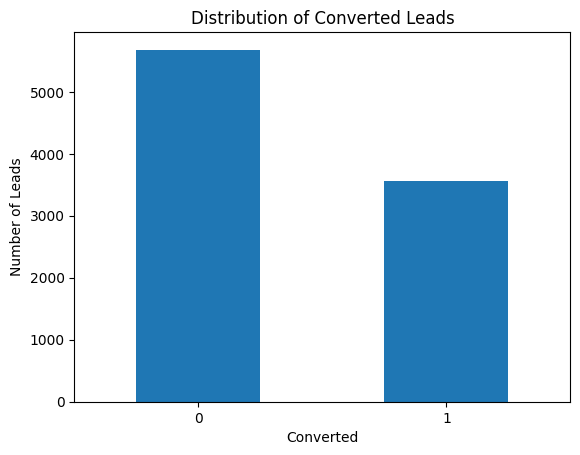

In [47]:
df['Converted'].value_counts().plot(kind='bar')

plt.title('Distribution of Converted Leads')
plt.xlabel('Converted')
plt.ylabel('Number of Leads')
plt.xticks(rotation=0)
plt.show()

### Observation – Target Distribution

The target contains 61.46% non-converted and 38.54% converted leads. The classes are moderately imbalanced, but not severely skewed.

### 6.2 Numerical Features vs Conversion

Numerical engagement features are compared across converted and non-converted leads to identify differences in user behavior and potential predictive relationships.

In [48]:
numeric_features = [
    'TotalVisits',
    'Total Time Spent on Website',
    'Page Views Per Visit'
]

df.groupby('Converted')[numeric_features].mean()

,TotalVisits,Total Time Spent on Website,Page Views Per Visit
Converted,,,
0,3.329670,330.404473,2.368453
1,3.633632,738.546757,2.353638


### Observation – Numerical Features

Converted leads spend considerably more time on the website and make slightly more visits. `Page Views Per Visit` shows little difference between the two groups.

### 6.3 Categorical Features vs Conversion

Important categorical features are compared using conversion rates to identify categories associated with higher or lower conversion likelihood.

In [49]:
categorical_features = [
    'Lead Origin',
    'Lead Source',
    'Lead Quality',
    'Country',
    'Specialization',
    'What is your current occupation',
    'Last Activity'
]

for col in categorical_features:
    print(f"\n--- {col} ---")
    print(
        df.groupby(col)['Converted']
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )


--- Lead Origin ---
Lead Origin
Quick Add Form             1.000000
Lead Add Form              0.924791
Landing Page Submission    0.361850
API                        0.311453
Lead Import                0.236364
Name: Converted, dtype: float64

--- Lead Source ---
Lead Source
Live Chat           1.000000
WeLearn             1.000000
NC_EDM              1.000000
Welingak Website    0.985915
Reference           0.917603
Click2call          0.750000
Social Media        0.500000
Google              0.404959
Organic Search      0.377816
Direct Traffic      0.321667
Name: Converted, dtype: float64

--- Lead Quality ---
Lead Quality
High in Relevance    0.946625
Low in Relevance     0.818182
Might be             0.755769
Not Sure             0.243590
Unknown              0.214810
Worst                0.019967
Name: Converted, dtype: float64

--- Country ---
Country
Denmark                1.000000
Hong Kong              0.571429
Bahrain                0.571429
Oman                   0.500000


### Observation – Categorical Features

Several categorical features show differences in conversion rates across categories. Some categories have very small sample sizes, so their extreme conversion rates should not be treated as reliable patterns.

### 6.4 Correlation Analysis

Correlation is examined among numerical features to identify relationships, potential redundancy, and their association with the target variable.

In [50]:
# Correlation matrix for numerical features
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

corr_matrix['Converted'].sort_values(ascending=False)

,Converted
Converted,1.000000
Total Time Spent on Website,0.362483
TotalVisits,0.030395
Page Views Per Visit,-0.003328


### Observation – Correlation Analysis

`Total Time Spent on Website` has the strongest numerical correlation with conversion, while `TotalVisits` shows a weak positive relationship and `Page Views Per Visit` has almost no linear correlation with the target.

In [51]:
# Review potentially time-dependent features
leakage_features = ['Lead Quality', 'Last Activity']

for col in leakage_features:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(15))


--- Lead Quality ---
Lead Quality
Unknown              4767
Might be             1560
Not Sure             1092
High in Relevance     637
Worst                 601
Low in Relevance      583
Name: count, dtype: int64

--- Last Activity ---
Last Activity
Email Opened                    3540
SMS Sent                        2745
Olark Chat Conversation          973
Page Visited on Website          640
Converted to Lead                428
Email Bounced                    326
Email Link Clicked               267
Form Submitted on Website        116
Unreachable                       93
Unsubscribed                      61
Had a Phone Conversation          30
Approached upfront                 9
View in browser link Clicked       6
Email Marked Spam                  2
Email Received                     2
Name: count, dtype: int64


In [52]:
# Check relationship of potentially time-dependent features with target

for col in ['Lead Quality', 'Last Activity']:
    print(f"\n--- {col} vs Converted ---")
    print(pd.crosstab(
        df[col],
        df['Converted'],
        normalize='index'
    ).sort_values(1, ascending=False).head(15))


--- Lead Quality vs Converted ---
Converted                 0         1
Lead Quality                         
High in Relevance  0.053375  0.946625
Low in Relevance   0.181818  0.818182
Might be           0.244231  0.755769
Not Sure           0.756410  0.243590
Unknown            0.785190  0.214810
Worst              0.980033  0.019967

--- Last Activity vs Converted ---
Converted                            0         1
Last Activity                                   
Approached upfront            0.000000  1.000000
Email Marked Spam             0.000000  1.000000
Email Received                0.000000  1.000000
Resubscribed to emails        0.000000  1.000000
Had a Phone Conversation      0.266667  0.733333
SMS Sent                      0.370856  0.629144
Email Opened                  0.623164  0.376836
Unreachable                   0.666667  0.333333
Email Link Clicked            0.726592  0.273408
Unsubscribed                  0.737705  0.262295
Form Submitted on Website     0.75862

### Observation – Leakage Review

`Lead Quality` and `Last Activity` show useful relationships with conversion and do not directly contain the target variable. They are retained for model development under the assumption that these features are available at the time the lead is scored.

However, these features may contain information generated from previous lead interactions. Therefore, in a production environment, only information available before the prediction point should be used to avoid temporal data leakage.

`Tags` was removed earlier because it may contain post-interaction status information and has a high proportion of missing values.

### 7.1 Train-Test Split

The dataset is divided into predictor variables and the target variable. An 80:20 stratified split is used to preserve the target distribution while keeping the test data unseen during model development.

In [53]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['Converted'])
y = df['Converted']

# Stratified 80:20 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train: (7392, 23)
X_test : (1848, 23)
y_train: (7392,)
y_test : (1848,)

Training target distribution:
Converted
0    61.458333
1    38.541667
Name: proportion, dtype: float64

Testing target distribution:
Converted
0    61.471861
1    38.528139
Name: proportion, dtype: float64


### 7.2 Feature Type Identification

Numerical and categorical predictors are identified separately to apply appropriate preprocessing before model training.

In [54]:
# Identify numerical and categorical features
numeric_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']

Categorical features:
['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Last Activity', 'Country', 'Specialization', 'How did you hear about X Education', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Lead Quality', 'City', 'A free copy of Mastering The Interview', 'Last Notable Activity']

Number of numerical features: 3
Number of categorical features: 20


### 7.3 Feature Preprocessing Pipeline

Numerical features are standardized and categorical features are one-hot encoded using a unified preprocessing pipeline. The pipeline is fitted only on the training data to prevent data leakage.

In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Numerical preprocessing
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


### 7.4 Baseline Model – Logistic Regression

Logistic Regression is used as the baseline model because the target is binary and the model provides an interpretable probability of conversion. Its performance will serve as a reference for comparing more complex classification algorithms.

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression pipeline
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train the model
logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### 7.5 Baseline Model Evaluation

The baseline model is evaluated using Accuracy, Precision, Recall, F1-score and ROC-AUC. Multiple metrics are used because the business objective requires identifying high-potential leads while avoiding unnecessary sales effort.

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Predictions
y_pred = logistic_pipeline.predict(X_test)

# Conversion probabilities
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.8268398268398268
Precision: 0.7873900293255132
Recall   : 0.7542134831460674
F1 Score : 0.7704447632711621
ROC-AUC  : 0.9031894138708657

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1136
           1       0.79      0.75      0.77       712

    accuracy                           0.83      1848
   macro avg       0.82      0.81      0.82      1848
weighted avg       0.83      0.83      0.83      1848



### 7.6 Decision Tree

A Decision Tree is trained to capture non-linear relationships and interactions between features. Its performance is compared with the Logistic Regression baseline.

In [58]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ))
])

# Train
decision_tree_pipeline.fit(X_train, y_train)

# Predictions
y_pred_dt = decision_tree_pipeline.predict(X_test)
y_prob_dt = decision_tree_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_dt))

Accuracy : 0.8430735930735931
Precision: 0.8625429553264605
Recall   : 0.7050561797752809
F1 Score : 0.7758887171561051
ROC-AUC  : 0.8893212681990822


### Decision Tree – Results

The Decision Tree improves accuracy and precision compared with the Logistic Regression baseline. However, its recall and ROC-AUC are lower, so further model comparison is required before selecting the final model.

### 7.7 Random Forest

Random Forest is trained as an ensemble model to capture complex feature relationships and improve generalization compared with a single Decision Tree.

In [59]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
random_forest_pipeline.fit(X_train, y_train)

# Predictions
y_pred_rf = random_forest_pipeline.predict(X_test)
y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.8501082251082251
Precision: 0.8330781010719756
Recall   : 0.7640449438202247
F1 Score : 0.7970695970695971
ROC-AUC  : 0.9148593280186738


### Random Forest – Results

Random Forest improves overall performance compared with the previous models, achieving 85.01% accuracy, 79.71% F1-score and 91.49% ROC-AUC. It currently performs best, but XGBoost will also be evaluated before selecting the final model.

### 7.8 XGBoost

XGBoost is evaluated as a gradient-boosting model to capture complex non-linear relationships and improve predictive performance on the lead conversion dataset.

In [60]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ))
])

# Train
xgb_pipeline.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))

Accuracy : 0.8544372294372294
Precision: 0.8392036753445635
Recall   : 0.7696629213483146
F1 Score : 0.802930402930403
ROC-AUC  : 0.9189040492957747


### Model Comparison – Initial Results

XGBoost achieved the best overall performance with 85.44% accuracy, 80.29% F1-score and 91.89% ROC-AUC. It provides the strongest balance between identifying converted leads and maintaining prediction quality among the evaluated models.

### 7.9 Feature Importance

Feature importance is analyzed using the best-performing XGBoost model to identify the features that contribute most to lead conversion.

In [61]:
# Get feature names after preprocessing
feature_names = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get XGBoost feature importance
importance = xgb_pipeline.named_steps['model'].feature_importances_

feature_importance = pd.Series(
    importance,
    index=feature_names
).sort_values(ascending=False)

feature_importance.head(15)

,0
cat__Lead Origin_Lead Add Form,0.124353
cat__Lead Source_Reference,0.078609
cat__What matters most to you in choosing a course_Unknown,0.062732
cat__Last Notable Activity_SMS Sent,0.056686
cat__Lead Quality_Unknown,0.054328
cat__Lead Quality_Not Sure,0.048159
cat__Lead Quality_Worst,0.043883
cat__Lead Quality_High in Relevance,0.041114
cat__Lead Quality_Might be,0.036334
num__Total Time Spent on Website,0.032134


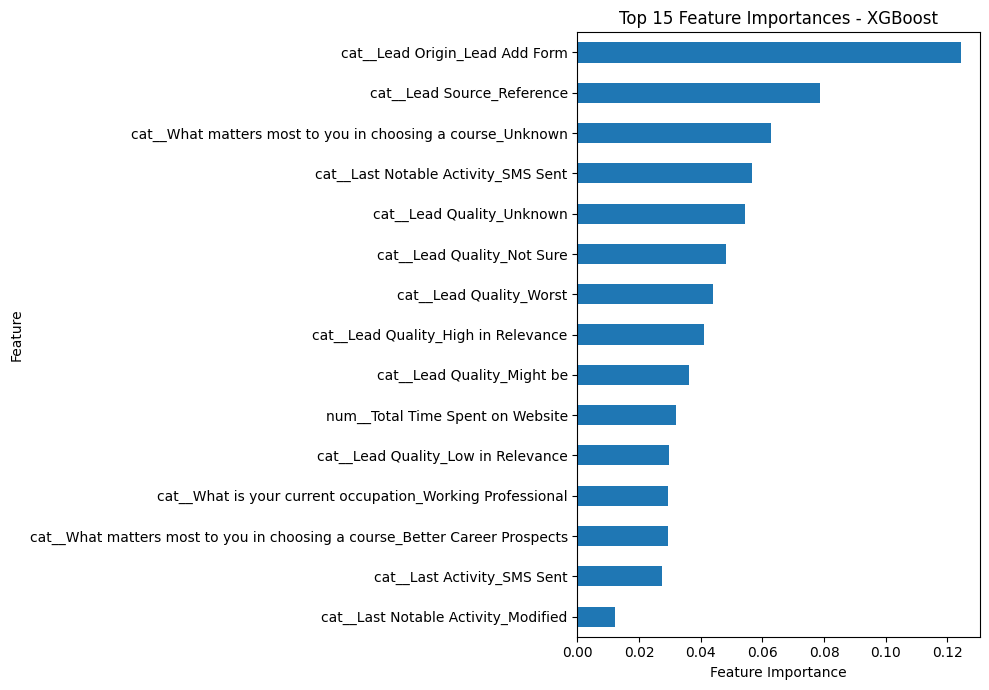

In [62]:
# Plot top 15 feature importances
top_features = feature_importance.head(15).sort_values(ascending=True)

plt.figure(figsize=(10, 7))

top_features.plot(kind='barh')

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances - XGBoost')

plt.tight_layout()
plt.show()

### Feature Importance – XGBoost

XGBoost identifies lead origin, lead source, recent activity, lead quality, course preference, and website engagement as important predictive factors for lead conversion.

Feature importance is used for interpretation rather than automatically removing low-importance features.

### 7.10 Model Comparison

The performance of all evaluated classification models is compared using the same evaluation metrics. This provides a clear basis for selecting the final model.

In [63]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8268,0.7874,0.7542,0.7704,0.9032
1,Decision Tree,0.8431,0.8625,0.7051,0.7759,0.8893
2,Random Forest,0.8501,0.8331,0.7640,0.7971,0.9149
3,XGBoost,0.8544,0.8392,0.7697,0.8029,0.9189


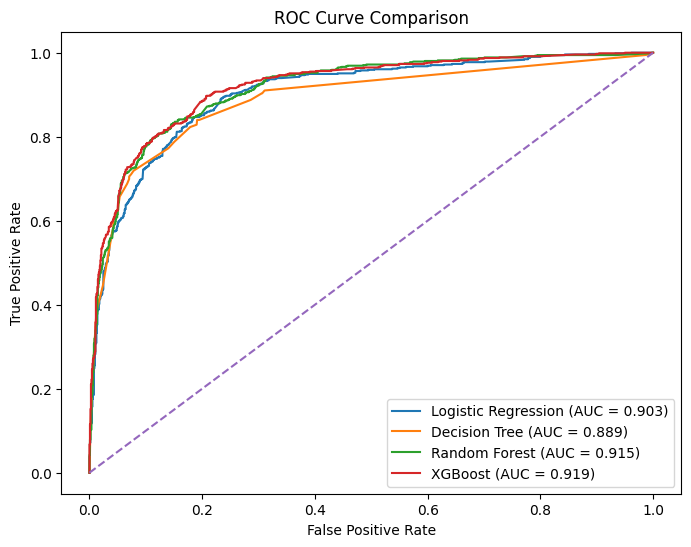

In [64]:
from sklearn.metrics import roc_curve

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr, tpr_lr,
    label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.3f})'
)

plt.plot(
    fpr_dt, tpr_dt,
    label=f'Decision Tree (AUC = {roc_auc_score(y_test, y_prob_dt):.3f})'
)

plt.plot(
    fpr_rf, tpr_rf,
    label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})'
)

plt.plot(
    fpr_xgb, tpr_xgb,
    label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})'
)

# Random classifier baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

<Figure size 1100x600 with 0 Axes>

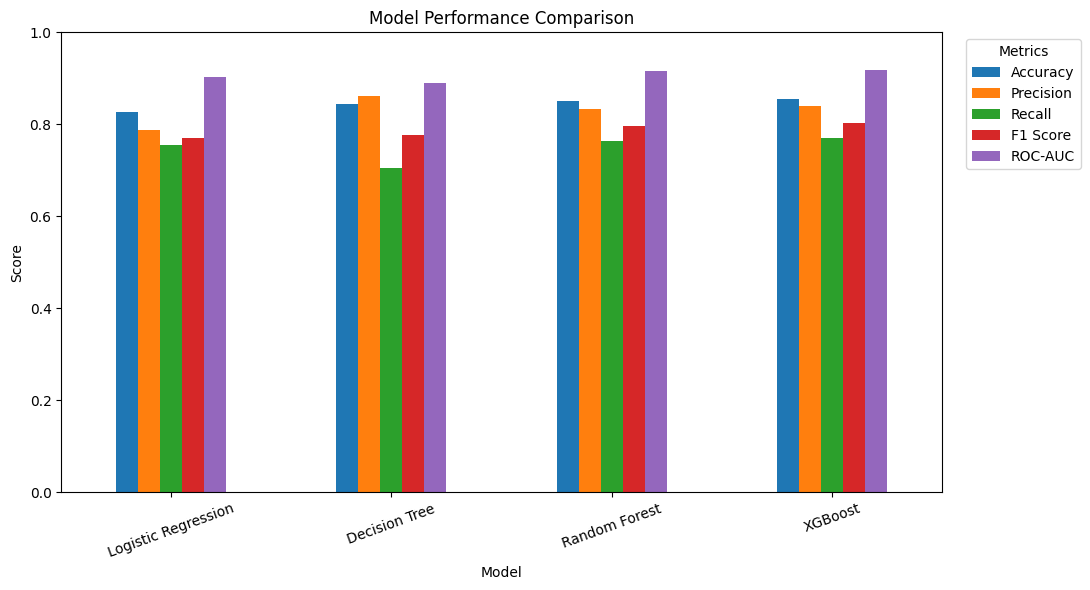

In [65]:
plt.figure(figsize=(11, 6))

model_results.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
].plot(kind='bar', figsize=(11, 6))

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.legend(
    title='Metrics',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### Model Selection

XGBoost was selected as the baseline model for hyperparameter tuning because it achieved the strongest overall performance among the evaluated models. It obtained the highest Accuracy (85.44%), F1-score (80.29%) and ROC-AUC (91.89%), while maintaining a good balance between precision and recall.

The selected XGBoost model was subsequently optimized using RandomizedSearchCV with cross-validation. The tuned model was then evaluated on the untouched test set to assess its final generalization performance.

### 7.11  XGBoost Hyperparameter Tuning

Hyperparameter tuning is performed using RandomizedSearchCV with 3-fold cross-validation on the training data. The search explores different combinations of XGBoost parameters such as the number of estimators, maximum depth, learning rate, subsampling ratio, and column sampling ratio.

ROC-AUC is used as the optimization metric because it evaluates the model's ability to distinguish between converted and non-converted leads across different classification thresholds.

In [66]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__max_depth': [3, 4, 5, 6],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=15,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(random_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.9}

Best Cross-Validation ROC-AUC:
0.9382504597519311


### Hyperparameter Tuning – Results

RandomizedSearchCV identified an improved XGBoost configuration with a cross-validation ROC-AUC of 93.83%. The tuned model will now be evaluated on the untouched test set to measure its final generalization performance.

In [67]:
# Best tuned model
best_xgb = random_search.best_estimator_

# Predictions on untouched test data
y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

print("Tuned XGBoost Results")
print("--------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_tuned))

Tuned XGBoost Results
--------------------
Accuracy : 0.8506493506493507
Precision: 0.8244047619047619
Recall   : 0.7780898876404494
F1 Score : 0.8005780346820809
ROC-AUC  : 0.9198041125969298


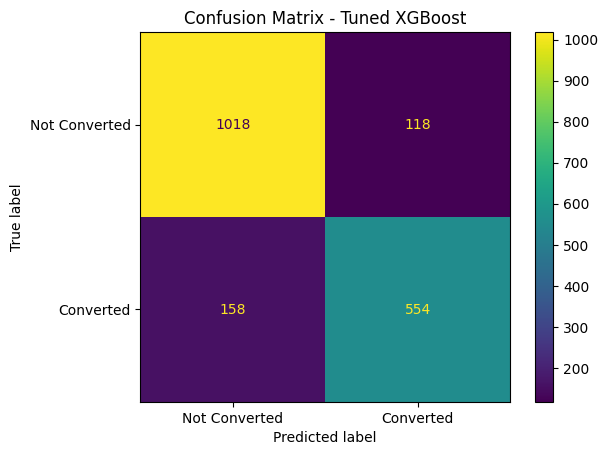

In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Converted', 'Converted']
)

disp.plot()

plt.title('Confusion Matrix - Tuned XGBoost')
plt.show()

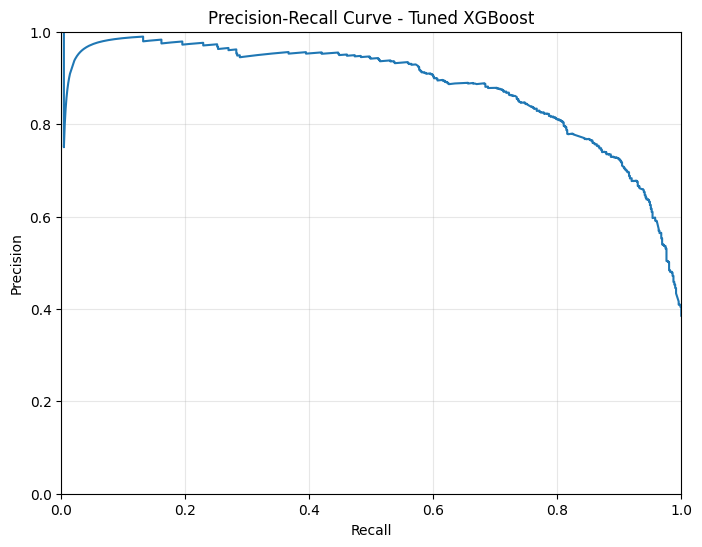

In [69]:
from sklearn.metrics import precision_recall_curve

# Calculate Precision-Recall curve
precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob_tuned
)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))

plt.plot(recall, precision)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Tuned XGBoost')

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.grid(alpha=0.3)
plt.show()

### Tuned XGBoost – Final Evaluation

The tuned XGBoost model achieved 85.06% accuracy, 82.40% precision, 77.81% recall, 80.06% F1-score and 91.98% ROC-AUC on the unseen test set.

Compared with the original XGBoost model, hyperparameter tuning produced a small improvement in ROC-AUC and recall. Accuracy and F1-score decreased slightly, while precision also decreased marginally. The tuned model is retained because it provides a strong ROC-AUC and improved recall, which is important for identifying a larger proportion of leads that are likely to convert.

### 7.12 Test-Set Lead Conversion Scoring

The final tuned XGBoost model is used to generate conversion probabilities for the unseen test set. These probabilities are converted into a 0–100 lead score to analyze the model's predictions on unseen data.

In [70]:
# Generate conversion probabilities
lead_probabilities = best_xgb.predict_proba(X_test)[:, 1]

# Convert probability to a 0-100 score
lead_scores = lead_probabilities * 100

lead_scoring = pd.DataFrame({
    'Conversion_Probability': lead_probabilities,
    'Lead_Score': lead_scores
}, index=X_test.index)

lead_scoring['Lead_Score'] = lead_scoring['Lead_Score'].round(2)

lead_scoring.head(10)

,Conversion_Probability,Lead_Score
683,0.289284,28.930000
1931,0.223767,22.379999
6950,0.171479,17.150000
2996,0.051350,5.140000
3902,0.074275,7.430000
6828,0.080748,8.070000
4906,0.277446,27.740000
5796,0.074966,7.500000
6388,0.069805,6.980000
3636,0.015504,1.550000


### 7.13 Test-Set Lead Score Distribution

The distribution of predicted lead scores is analyzed to understand the range of conversion probabilities and define meaningful lead-priority categories.

In [71]:
lead_scoring['Lead_Score'].describe()

,Lead_Score
count,1848.000000
mean,38.742386
std,37.773952
min,0.120000
25%,4.030000
50%,23.170000
75%,81.869997
max,99.639999


In [72]:
lead_scoring['Lead_Score'].quantile([0.25, 0.50, 0.75])

,Lead_Score
0.25,4.030000
0.50,23.170000
0.75,81.869997


### 7.14 Lead Priority Classification

Lead scores are converted into Low, Medium and High priority groups using percentile-based thresholds. For the final scoring of all available leads, the 25th and 75th percentiles of the complete lead-score distribution are used as the thresholds.

- **Low:** Bottom 25% of scored leads
- **Medium:** Middle 50% of scored leads
- **High:** Top 25% of scored leads

This approach ensures that lead priorities are determined relative to the score distribution of the complete lead population rather than using arbitrary fixed cutoffs.

### 7.15 Final Lead Scoring

The final tuned XGBoost model is used to generate conversion scores for all available leads. The target variable is excluded from the final scoring output because it represents the actual conversion outcome and would not be available for new leads.

In [73]:
# Generate conversion probabilities for all leads
all_lead_probabilities = best_xgb.predict_proba(X)[:, 1]

# Create final scoring dataset
final_lead_scoring = df.drop(columns=['Converted']).copy()

# Add model-generated scores
final_lead_scoring['Conversion_Probability'] = all_lead_probabilities

final_lead_scoring['Lead_Score'] = (
    all_lead_probabilities * 100
).round(2)

# Calculate thresholds using all scored leads
low_threshold = final_lead_scoring['Lead_Score'].quantile(0.25)
high_threshold = final_lead_scoring['Lead_Score'].quantile(0.75)

# Assign lead priority
final_lead_scoring['Lead_Priority'] = pd.cut(
    final_lead_scoring['Lead_Score'],
    bins=[-float('inf'), low_threshold, high_threshold, float('inf')],
    labels=['Low', 'Medium', 'High']
)

# Sort highest-priority leads first
final_lead_scoring = final_lead_scoring.sort_values(
    'Lead_Score',
    ascending=False
)

print("Low threshold :", round(low_threshold, 2))
print("High threshold:", round(high_threshold, 2))

final_lead_scoring.head(10)


Low threshold : 3.87
High threshold: 83.11


,Lead Origin,Lead Source,Do Not Email,Do Not Call,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,...,Newspaper,Digital Advertisement,Through Recommendations,Lead Quality,City,A free copy of Mastering The Interview,Last Notable Activity,Conversion_Probability,Lead_Score,Lead_Priority
4984,Landing Page Submission,Direct Traffic,No,No,7.0,1500,2.33,SMS Sent,India,IT Projects Management,...,No,No,No,High in Relevance,Mumbai,No,SMS Sent,0.997602,99.760002,High
7978,API,Organic Search,No,No,7.0,987,1.17,SMS Sent,India,IT Projects Management,...,No,No,No,High in Relevance,Mumbai,No,SMS Sent,0.996605,99.660004,High
9016,Landing Page Submission,Direct Traffic,No,No,25.0,1569,2.08,Email Opened,India,Business Administration,...,No,No,No,High in Relevance,Mumbai,Yes,Email Opened,0.996508,99.650002,High
7105,API,Olark Chat,No,No,10.0,1290,2.00,SMS Sent,India,Travel and Tourism,...,No,No,No,High in Relevance,Other Cities of Maharashtra,Yes,SMS Sent,0.996418,99.639999,High
3078,Lead Add Form,Reference,No,No,0.0,0,0.00,SMS Sent,Unknown,Human Resource Management,...,No,No,No,High in Relevance,Unknown,No,SMS Sent,0.996362,99.639999,High
737,Lead Add Form,Welingak Website,No,No,0.0,0,0.00,Email Opened,Unknown,Finance Management,...,No,No,No,High in Relevance,Mumbai,No,Email Opened,0.996276,99.629997,High
4955,API,Google,No,No,9.0,1416,1.80,SMS Sent,India,Human Resource Management,...,No,No,No,Might be,Mumbai,No,SMS Sent,0.996300,99.629997,High
1758,Lead Add Form,Welingak Website,No,No,0.0,0,0.00,Email Opened,Unknown,Human Resource Management,...,No,No,No,High in Relevance,Other Cities of Maharashtra,No,Email Opened,0.995967,99.599998,High
8946,Landing Page Submission,Organic Search,No,No,10.0,1361,2.50,SMS Sent,India,Human Resource Management,...,No,No,No,Might be,Other Metro Cities,Yes,SMS Sent,0.995845,99.580002,High
4662,Lead Add Form,Welingak Website,No,No,1.0,846,1.00,Page Visited on Website,Unknown,Unknown,...,No,No,No,High in Relevance,Unknown,No,Modified,0.995591,99.559998,High


### 7.16 Final Lead Priority Distribution

The final lead scores are grouped into Low, Medium and High priority categories. The distribution is examined to understand how leads are allocated for sales prioritization.

In [74]:
print("Final Lead Priority Distribution:")
print(final_lead_scoring['Lead_Priority'].value_counts())

print("\nPercentage Distribution:")
print(
    final_lead_scoring['Lead_Priority']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Final Lead Priority Distribution:
Lead_Priority
Medium    4619
Low       2311
High      2310
Name: count, dtype: int64

Percentage Distribution:
Lead_Priority
Medium    49.99
Low       25.01
High      25.00
Name: proportion, dtype: float64


In [75]:
final_lead_scoring[
    ['Conversion_Probability', 'Lead_Score']
].describe()

,Conversion_Probability,Lead_Score
count,9240.000000,9240.000000
mean,0.385839,38.583755
std,0.380518,38.052357
min,0.001141,0.110000
25%,0.038723,3.870000
50%,0.222889,22.290001
75%,0.831144,83.112501
max,0.997602,99.760002


### 7.17 Top High-Priority Leads

The highest-scoring leads are identified to demonstrate how the lead scoring system can support sales prioritization.

In [76]:
top_leads = final_lead_scoring[
    final_lead_scoring['Lead_Priority'] == 'High'
].sort_values(
    'Lead_Score',
    ascending=False
)

top_leads[
    [
        'Lead Origin',
        'Lead Source',
        'Lead Quality',
        'Last Activity',
        'TotalVisits',
        'Total Time Spent on Website',
        'Conversion_Probability',
        'Lead_Score',
        'Lead_Priority'
    ]
].head(10)

,Lead Origin,Lead Source,Lead Quality,Last Activity,TotalVisits,Total Time Spent on Website,Conversion_Probability,Lead_Score,Lead_Priority
4984,Landing Page Submission,Direct Traffic,High in Relevance,SMS Sent,7.0,1500,0.997602,99.760002,High
7978,API,Organic Search,High in Relevance,SMS Sent,7.0,987,0.996605,99.660004,High
9016,Landing Page Submission,Direct Traffic,High in Relevance,Email Opened,25.0,1569,0.996508,99.650002,High
7105,API,Olark Chat,High in Relevance,SMS Sent,10.0,1290,0.996418,99.639999,High
3078,Lead Add Form,Reference,High in Relevance,SMS Sent,0.0,0,0.996362,99.639999,High
737,Lead Add Form,Welingak Website,High in Relevance,Email Opened,0.0,0,0.996276,99.629997,High
4955,API,Google,Might be,SMS Sent,9.0,1416,0.996300,99.629997,High
1758,Lead Add Form,Welingak Website,High in Relevance,Email Opened,0.0,0,0.995967,99.599998,High
8946,Landing Page Submission,Organic Search,Might be,SMS Sent,10.0,1361,0.995845,99.580002,High
4662,Lead Add Form,Welingak Website,High in Relevance,Page Visited on Website,1.0,846,0.995591,99.559998,High


### 7.18 Business Insights

The lead scoring model provides actionable insights for prioritizing sales efforts. High-priority leads have the highest predicted likelihood of conversion and should receive immediate attention, while medium-priority leads can be handled through regular follow-up and low-priority leads can be targeted through automated or lower-cost engagement strategies.

The model also indicates that lead origin, lead source, lead quality, recent activity and website engagement are important factors associated with conversion.

In [77]:
print("Business Summary")
print("----------------")
print(f"Total leads scored: {len(final_lead_scoring)}")
print(f"High-priority leads: {(final_lead_scoring['Lead_Priority'] == 'High').sum()}")
print(f"Medium-priority leads: {(final_lead_scoring['Lead_Priority'] == 'Medium').sum()}")
print(f"Low-priority leads: {(final_lead_scoring['Lead_Priority'] == 'Low').sum()}")

print("\nAverage Lead Score by Priority:")
print(
    final_lead_scoring
    .groupby('Lead_Priority', observed=True)['Lead_Score']
    .mean()
    .round(2)
)

Business Summary
----------------
Total leads scored: 9240
High-priority leads: 2310
Medium-priority leads: 4619
Low-priority leads: 2311

Average Lead Score by Priority:
Lead_Priority
Low        1.750000
Medium    29.230000
High      94.139999
Name: Lead_Score, dtype: float32


In [78]:
# Final validation
print("Final dataset shape:", final_lead_scoring.shape)
print("Target variable present:", 'Converted' in final_lead_scoring.columns)

print("\nMissing values in original lead attributes:",
      final_lead_scoring.drop(
          columns=['Conversion_Probability', 'Lead_Score', 'Lead_Priority']
      ).isnull().sum().sum())

print("\nMissing values in model-generated fields:",
      final_lead_scoring[
          ['Conversion_Probability', 'Lead_Score', 'Lead_Priority']
      ].isnull().sum().sum())

Final dataset shape: (9240, 26)
Target variable present: False

Missing values in original lead attributes: 274

Missing values in model-generated fields: 0


In [79]:
# Export final lead scoring results
final_lead_scoring.to_csv(
    'lead_scoring_results.csv',
    index=False
)

print("Lead scoring results exported successfully.")

Lead scoring results exported successfully.


## 8. Conclusion

This project successfully developed a machine learning-based Lead Conversion Prediction and Lead Scoring system.

Multiple classification algorithms including Logistic Regression, Decision Tree, Random Forest and XGBoost were evaluated using Accuracy, Precision, Recall, F1-score and ROC-AUC. XGBoost demonstrated the strongest overall baseline performance and was therefore selected for hyperparameter tuning.

The tuned XGBoost model achieved strong performance on the unseen test data, with a ROC-AUC of approximately 91.98%. The model was then used to generate conversion probabilities for all available leads. These probabilities were converted into a 0–100 Lead Score and categorized into Low, Medium and High priority groups using percentile-based thresholds.

The resulting lead scores can help sales teams prioritize high-potential leads, allocate follow-up efforts more effectively and reduce the time spent on lower-probability leads.

Overall, the project demonstrates how machine learning can be applied not only for prediction but also to support practical business decision-making through lead prioritization.